# PEEC vs BEM-A Convergence on 3turnCoil

This notebook is the public, result-saved view of the 2026-05-13 3turnCoil convergence record. The raw sweep data now lives in this docs topic so long-lived documentation can point to docs artifacts rather than the examples tree.

The result is intentionally framed as a convergence and method-comparison record, not as an analytical validation: this geometry has lead bars and no closed-form ground truth.

In [1]:
from pathlib import Path
import json

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'peec_bema_convergence_results.json').exists():
    NOTEBOOK_DIR = Path('docs/peec_bema_convergence').resolve()
DATA = json.loads((NOTEBOOK_DIR / 'peec_bema_convergence_results.json').read_text(encoding='utf-8'))
RAW = DATA['raw_payload']
print(json.dumps(DATA['summary'], ensure_ascii=False, indent=2))


{
  "geometry": "3-turn pancake helix R_avg~35mm + r_wire=3.15mm, 2 lead bars 60-61mm at y=+/-12.5mm",
  "frequency_Hz": 150000,
  "current_A": 1.0,
  "peec_points": 6,
  "peec_n_peri_min": 8,
  "peec_n_peri_max": 64,
  "peec_L_nH_min": 423.895,
  "peec_L_nH_max": 431.551,
  "peec_L_inf_est_nH": 434.0,
  "production_n_peri": 16,
  "production_L_nH": 426.3,
  "production_deviation_from_inf_pct": -1.78,
  "bema_points": 3,
  "bema_L_nH_min": 412.18,
  "bema_L_nH_max": 432.57,
  "bema_unreachable_cases": 1,
  "potential_gap_pct": "5-8%"
}


## Recorded Physics

The PEEC sweep changes the perimeter filament count on the same lead-aware STEP geometry. The BEM-A sweep changes the surface mesh used by the HDiv/SIBC surface formulation. The 14,972-triangle BEM-A case is recorded as unreachable on this machine because the dense saddle solve exceeded practical memory/time.

In [2]:
from IPython.display import Markdown, display

peec_rows = RAW['peec_convergence']['data']
bema_rows = RAW['bema_convergence']['data']
lines = ['| method | resolution | L [nH] | R [mOhm] | time [s] |', '| --- | ---: | ---: | ---: | ---: |']
for row in peec_rows:
    lines.append(f"| PEEC | n_peri={row['n_peri']} | {row['L_nH']:.3f} | {row['R_mOhm']:.5f} | {row['time_s']:.2f} |")
for row in bema_rows:
    lines.append(f"| BEM-A | tris={row['n_tris']} | {row['L_nH']:.3f} | {row['R_mOhm_SIBC']:.3f} | {row['time_s']:.1f} |")
display(Markdown('\n'.join(lines)))


| method | resolution | L [nH] | R [mOhm] | time [s] |
| --- | ---: | ---: | ---: | ---: |
| PEEC | n_peri=8 | 423.895 | 0.39742 | 12.16 |
| PEEC | n_peri=16 | 426.296 | 0.39452 | 15.10 |
| PEEC | n_peri=24 | 428.083 | 0.39123 | 20.15 |
| PEEC | n_peri=32 | 429.262 | 0.38931 | 29.76 |
| PEEC | n_peri=48 | 430.716 | 0.38706 | 53.13 |
| PEEC | n_peri=64 | 431.551 | 0.38591 | 88.02 |
| BEM-A | tris=4028 | 432.570 | 5.084 | 170.0 |
| BEM-A | tris=5938 | 417.560 | 4.762 | 460.4 |
| BEM-A | tris=9848 | 412.180 | 4.717 | 1591.0 |

## Main Takeaway

The PEEC sequence is monotone in this sweep and gives a continuum estimate near 434 nH. The BEM-A sequence is non-monotone at the recorded resolutions and could not be pushed above 10k triangles with the dense path. The production PEEC default `n_peri=16` remains an engineering compromise: fast and within about 2% of the PEEC extrapolated value, while the independent BEM-A continuum needs an accelerated path before it can be treated as decisive.

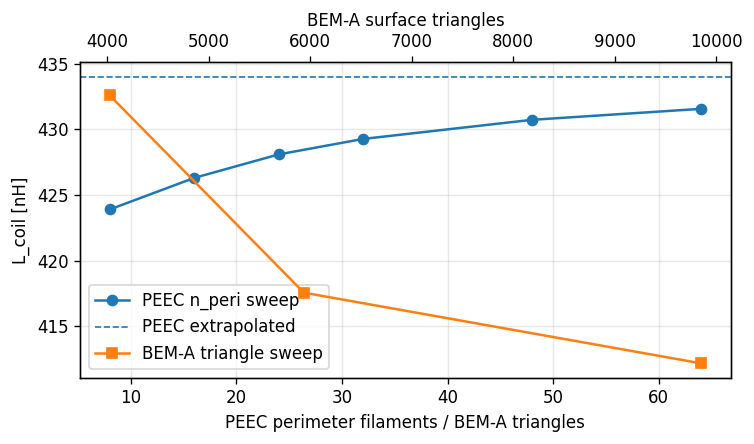

In [3]:
import matplotlib.pyplot as plt

peec_x = [row['n_peri'] for row in peec_rows]
peec_y = [row['L_nH'] for row in peec_rows]
bema_x = [row['n_tris'] for row in bema_rows]
bema_y = [row['L_nH'] for row in bema_rows]

fig, ax1 = plt.subplots(figsize=(6.4, 3.8), dpi=120)
ax1.plot(peec_x, peec_y, marker='o', label='PEEC n_peri sweep')
ax1.axhline(DATA['summary']['peec_L_inf_est_nH'], color='C0', linestyle='--', linewidth=1.0, label='PEEC extrapolated')
ax1.set_xlabel('PEEC perimeter filaments / BEM-A triangles')
ax1.set_ylabel('L_coil [nH]')
ax1.grid(True, alpha=0.3)
ax2 = ax1.twiny()
ax2.plot(bema_x, bema_y, marker='s', color='C1', label='BEM-A triangle sweep')
ax2.set_xlabel('BEM-A surface triangles')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
fig.tight_layout()
plt.show()


## Durable Result JSON

The adjacent `peec_bema_convergence_results.json` stores the raw payload, a compact summary, runtime/version metadata, and the SHA-256 of the raw promoted JSON. The separate `peec_bema_convergence_result.json` sidecar records this executed notebook's outputs and `notebook_sha256`.

In [4]:
assert DATA['schema'] == 'radia.docs.peec_bema_convergence.v1'
assert DATA['summary']['peec_points'] == 6
assert DATA['summary']['bema_points'] == 3
assert DATA['summary']['bema_unreachable_cases'] == 1
assert DATA['source_raw_json_sha256']
print('peec_bema_convergence notebook OK')


peec_bema_convergence notebook OK
